## Random Forest

#### 1. Exploratory Data Analysis (EDA)

In [53]:
import pandas as pd

# Load the Glass dataset
df = pd.read_csv(r"C:\Users\suraj\OneDrive\Desktop\data sets\glass1.csv") 

# Basic info
print(df.head())
print(df.info())
print(df.describe())

# Check for missing values
print(df.isnull().sum())

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0   1.0
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0   1.0
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0   1.0
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0   1.0
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0   1.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    float64
dtypes: float64(10)
memory usage: 78.2 KB
None
              

#### 2.Data Visualization

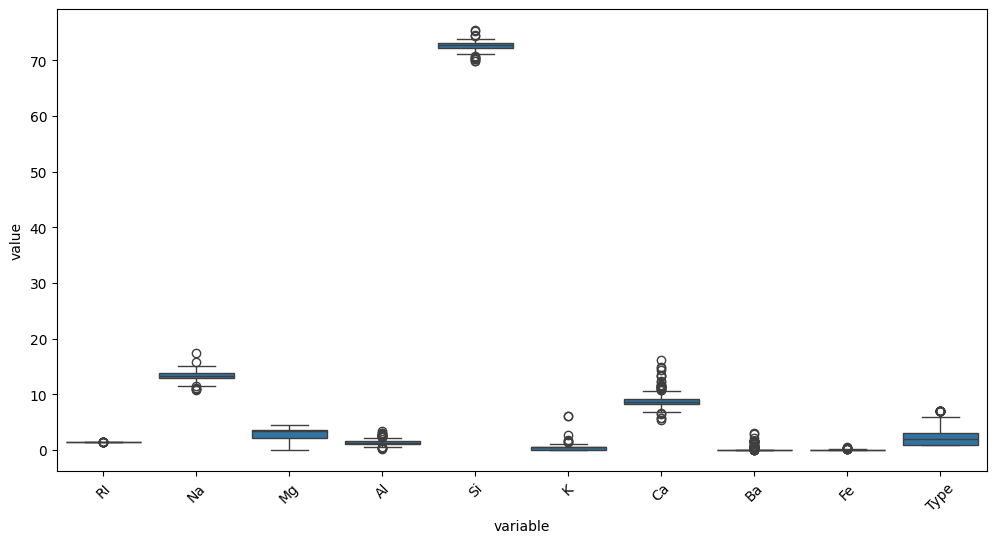

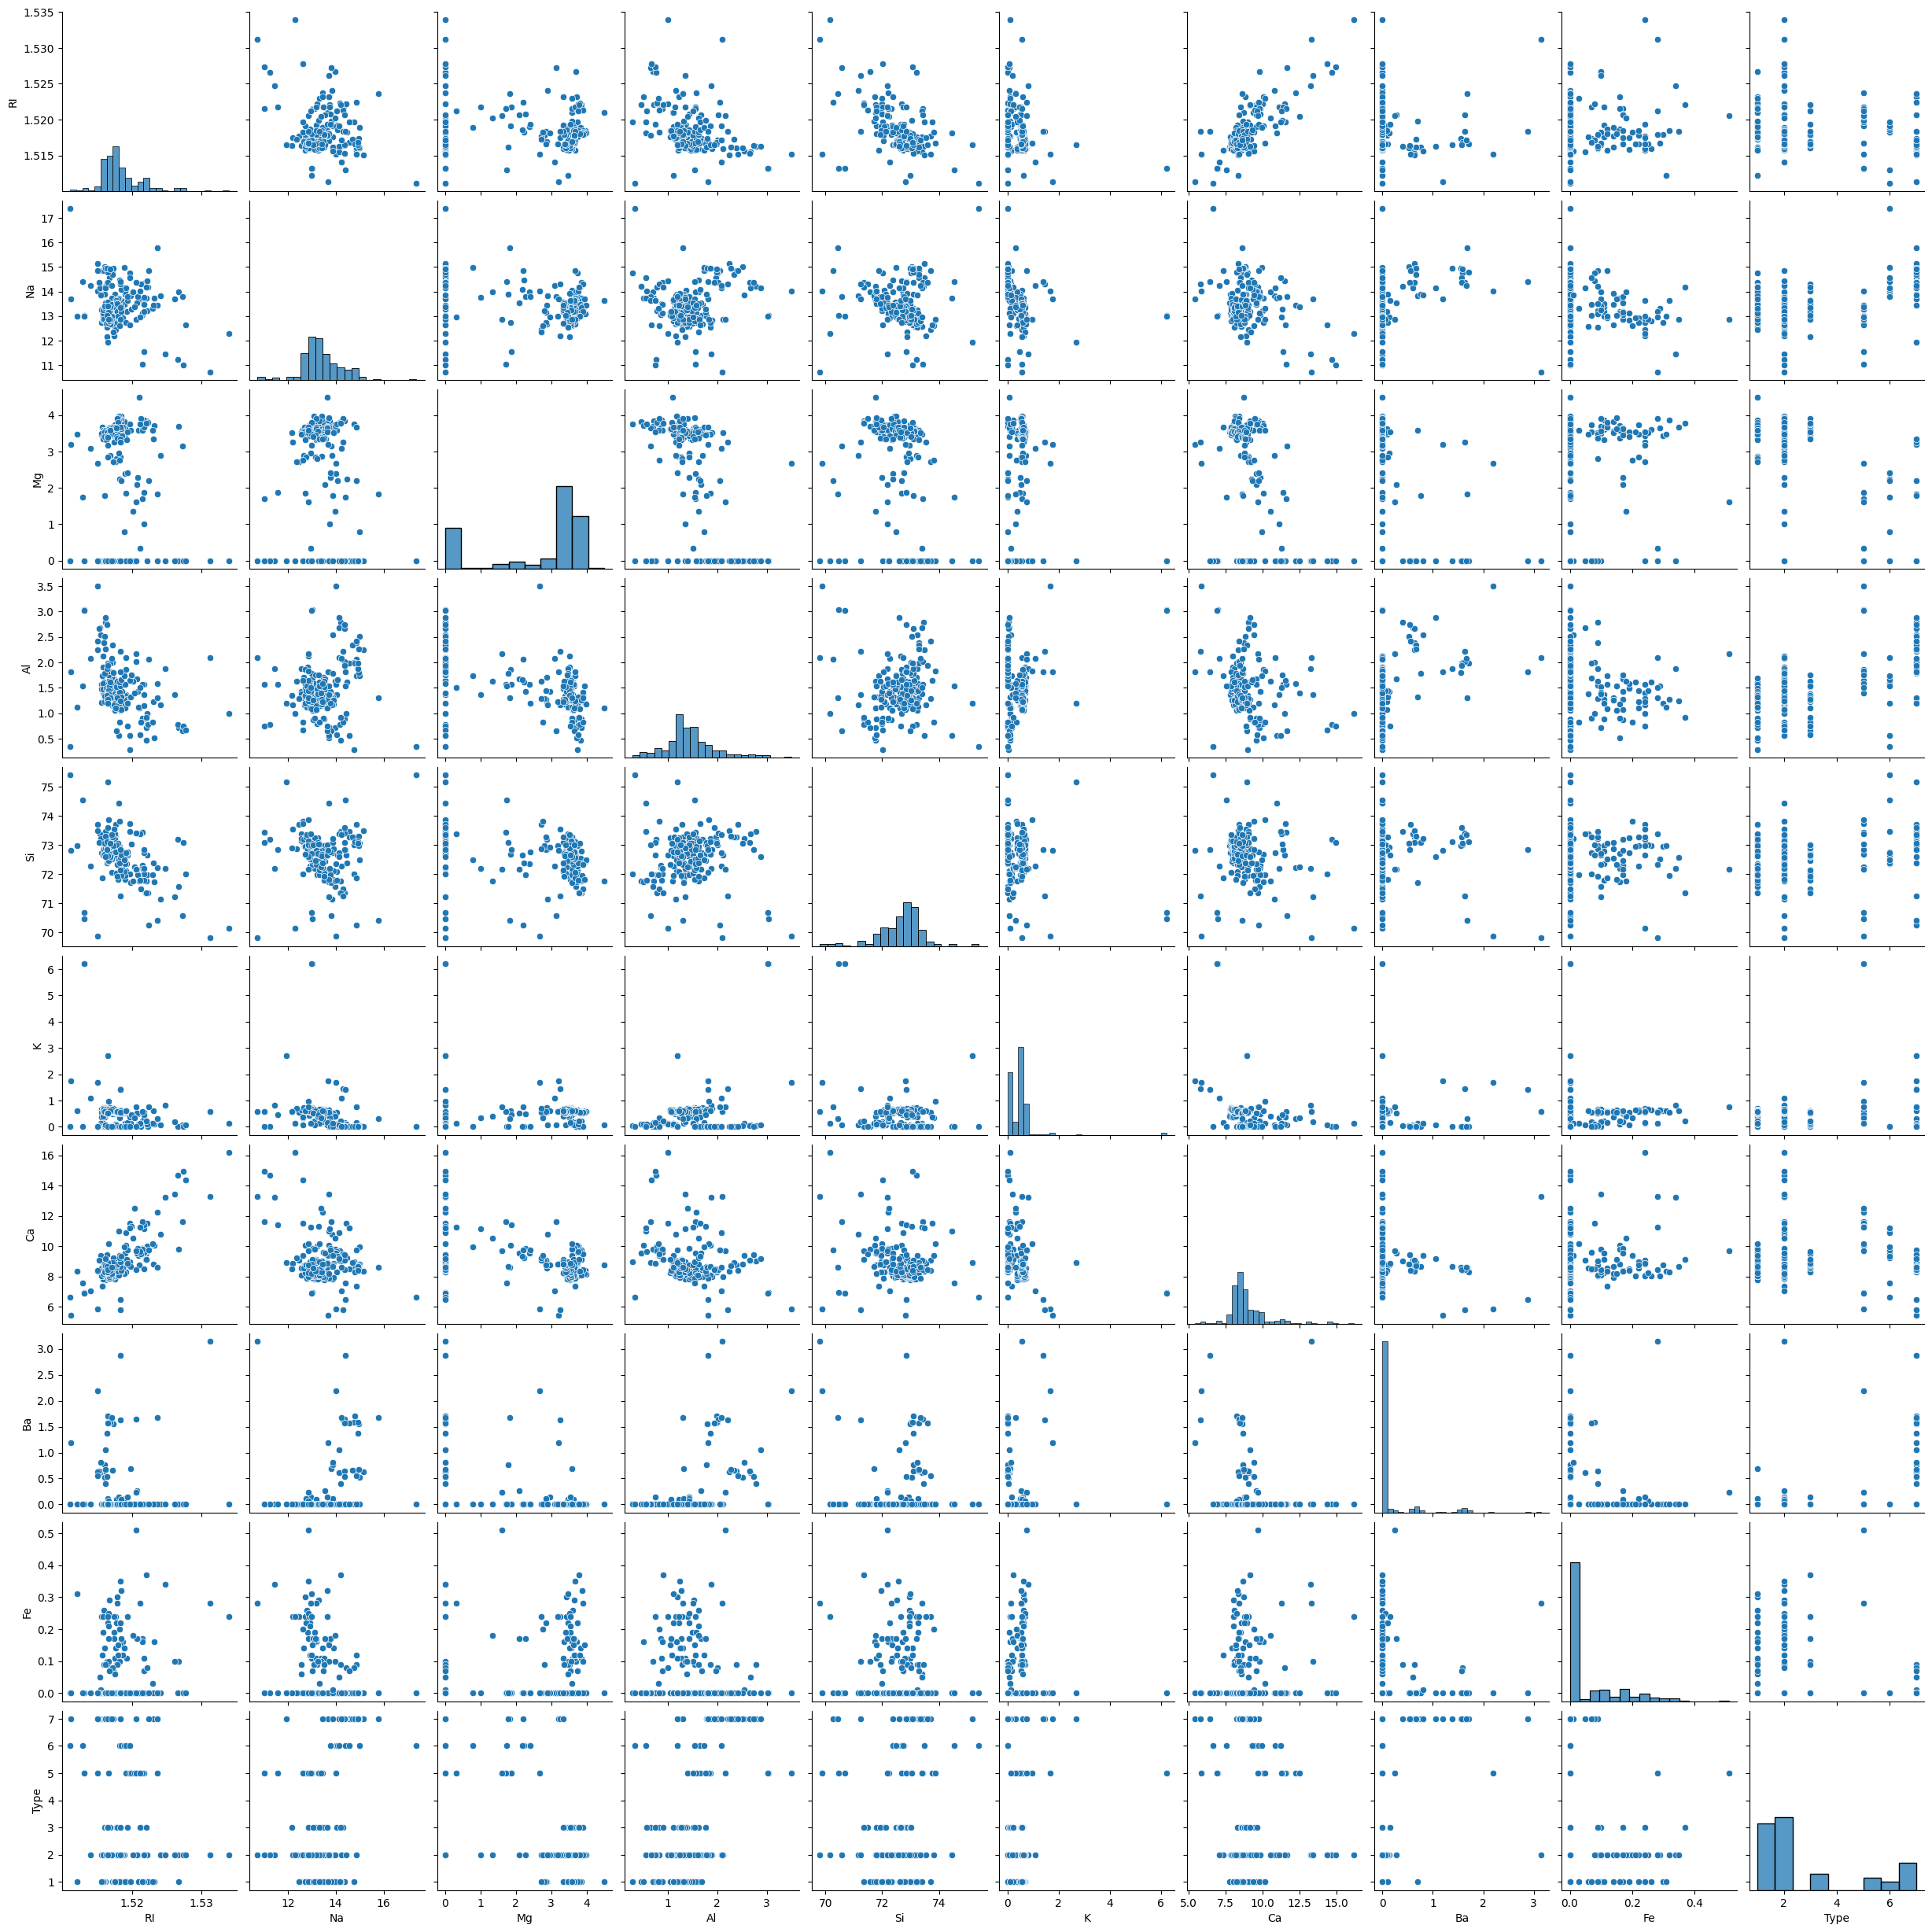

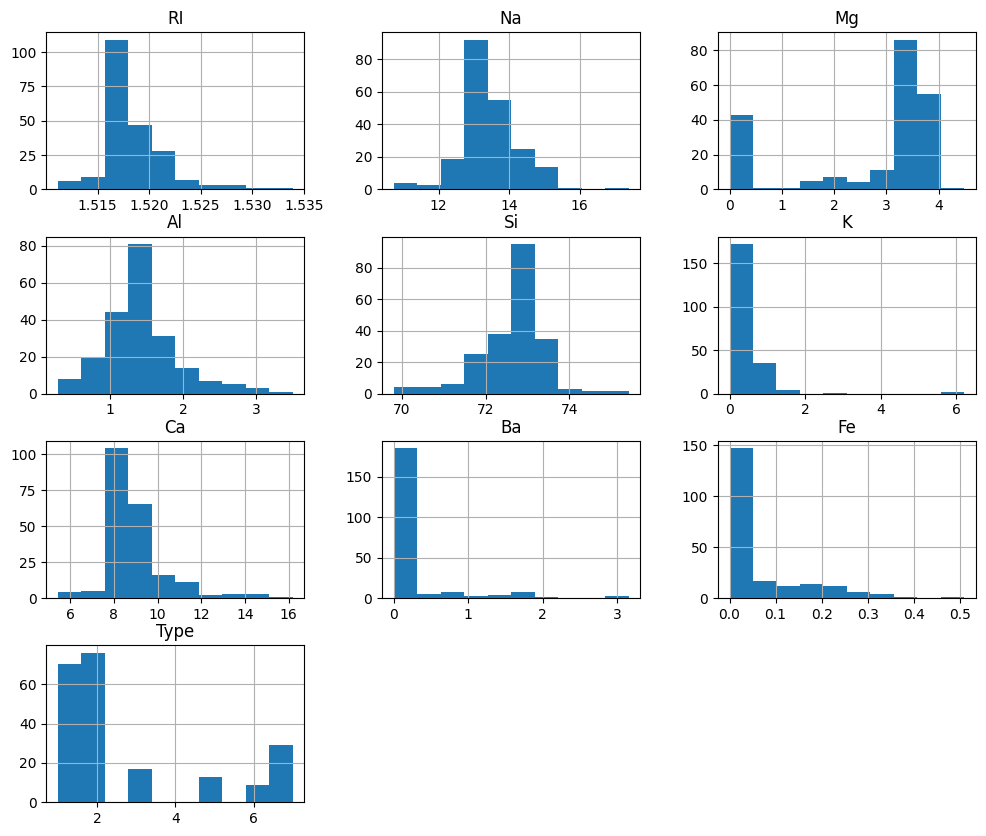

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert wide-form numeric columns to long-form
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df_long = pd.melt(df, value_vars=numeric_cols)

plt.figure(figsize=(12,6))
sns.boxplot(x='variable', y='value', data=df_long)
plt.xticks(rotation=45)
plt.show()

sns.pairplot(df)
plt.show()

df.hist(figsize=(12,10))
plt.show()

1. Handling Missing Values

In [55]:
# Check missing values
print(df.isnull().sum())

# Numerical columns → fill with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
     df[col] = df[col].fillna(df[col].median())

# Categorical columns → fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Final check
print(df.isnull().sum())

RI      785
Na      785
Mg      785
Al      785
Si      785
K       785
Ca      785
Ba      785
Fe      785
Type    785
dtype: int64
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [56]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

#### 3.Data Preprocessing

In [58]:
df = df.dropna(subset=['Type'])

In [59]:
print(df.columns)

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')


In [60]:
X = df.drop('Type', axis=1)
y = df['Type']

In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# If no headers in file, use this:
# df.columns = ['Id','RI','Na','Mg','Al','Si','K','Ca','Ba','Fe','Type']

# Drop Id if present
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Features and target
X = df.drop('Type', axis=1)
y = df['Type']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Preprocessing Done ")

Preprocessing Done 


#### 4.Random Forest Model Implementation

In [62]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# MUST run this BEFORE using X_res
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

# Now split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.988394584139265


In [64]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[169   8   0   0   0   0]
 [  1 184   0   0   0   0]
 [ 53  22  83   0   0   0]
 [  0   1   0 149   0  17]
 [  0   0   0   0 177   0]
 [  1   4   0   0   0 165]]
              precision    recall  f1-score   support

         1.0       0.75      0.95      0.84       177
         2.0       0.84      0.99      0.91       185
         3.0       1.00      0.53      0.69       158
         5.0       1.00      0.89      0.94       167
         6.0       1.00      1.00      1.00       177
         7.0       0.91      0.97      0.94       170

    accuracy                           0.90      1034
   macro avg       0.92      0.89      0.89      1034
weighted avg       0.91      0.90      0.89      1034



#### 5.Bagging and Boosting Methods

Bagging (Bootstrap Aggregating)

In [65]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Use 'estimator' instead of 'base_estimator' in newer scikit-learn
bag = BaggingClassifier(estimator=RandomForestClassifier(), n_estimators=50, random_state=42)
bag.fit(X_train, y_train)

# Predict and evaluate
y_pred_bag = bag.predict(X_test)
from sklearn.metrics import accuracy_score
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

Bagging Accuracy: 0.9854932301740812


Boosting 

In [66]:
# from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
boost = AdaBoostClassifier(n_estimators=50, random_state=42)
boost.fit(X_train, y_train)
y_pred_boost = boost.predict(X_test)
print("Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))

Boosting Accuracy: 0.6528046421663443


#### Additional Question

1. Explain Bagging and Boosting methods. How is it different from each other.


Models trained sequentially; each new model tries to fix previous errors.
Reduces bias, can improve accuracy on hard-to-predict samples.

Difference Between Bagging and Boosting:

Aspect	         Bagging	                   Boosting
Training	     Parallel, independent	       Sequential, dependent
Goal	         Reduce variance               Reduce bias & variance
Common Models	 Random Forest,Bagging Trees   AdaBoost, Gradient Boosting
    
EDA: Check data structure, outliers, and correlations.
Visualization: Histograms, box plots, pair plots, heatmaps.
Preprocessing: Handle missing values, encode categorical, scale features, handle imbalance.
Random Forest: Train, predict, evaluate metrics.
Bagging vs Boosting: Compare performance and understand differences.



2. Explain how to handle imbalance in the data.

Imbalanced data means one class has much more data than another (e.g., fraud detection).

Problems with Imbalanced Data
Model becomes biased toward majority class
Poor performance on minority class
Accuracy becomes misleading
Techniques to Handle Imbalance
1. Resampling Methods
a) Oversampling
Increase minority class samples
Techniques:
Random Oversampling
SMOTE (Synthetic Minority Over-sampling Technique)

b) Undersampling
Reduce majority class samples
Techniques:
Random Undersampling
Tomek Links

2. Algorithm-Level Methods
a) Class Weights
Assign higher weight to minority class
model = LogisticRegression(class_weight='balanced')
b) Cost-Sensitive Learning
Penalize wrong predictions more for minority class
3. Evaluation Metrics (Important!)
Precision
Recall
F1-Score
ROC-AUC

4. Ensemble Methods
Use Boosting (like AdaBoost, XGBoost)
Use Balanced Random Forest
Summary
Bagging → reduces variance, models run independently
Boosting → reduces bias, models learn sequentially from mistakes
Imbalanced Data Handling → use resampling, class weights, and better evaluation metrics
